<a href="https://colab.research.google.com/github/Muqtarali/Deep-Learning/blob/main/Data%20Augmentation/Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img
import os

In [7]:
!unzip "/content/cat image.zip"

unzip:  cannot find or open /content/cat image.zip, /content/cat image.zip.zip or /content/cat image.zip.ZIP.


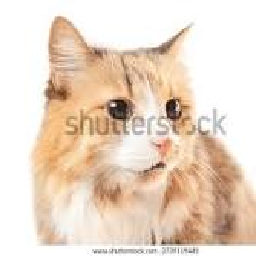

In [8]:
from tensorflow.keras.preprocessing import image
import numpy as np

# 1. Image load aur resize karein (Model shape according to 256x256)
img_path = "/content/cat image.jpg"
img = image.load_img(img_path, target_size=(256, 256))

# Image ko screen par dikhane ke liye
display(img)

In [11]:
os.makedirs("aug", exist_ok=True)

In [12]:
type(img)

PIL.Image.Image

In [13]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

In [14]:
img=image.img_to_array(img)


In [15]:
type(img)

numpy.ndarray

In [16]:
img.shape

(256, 256, 3)

In [17]:
input_batch=img.reshape(1,256,256,3)

In [ ]:
input_batch.shape

In [20]:
i=0
for output in datagen.flow(input_batch,batch_size=1,save_to_dir="aug",):
  i+=1
  if i>20:
    break

# For totel lable data **bold text**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. ImageDataGenerator Setup (Augmentation rules define karein)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Pixels ko 0-1 range me normalize karega
    rotation_range=40,        # 40 degree rotation
    width_shift_range=0.2,    # Horizontal shift
    height_shift_range=0.2,   # Vertical shift
    shear_range=0.2,          # Shear distortion
    zoom_range=0.2,           # Zoom in/out
    horizontal_flip=True,     # Left-Right flip
    fill_mode='nearest',
    validation_split=0.2      # 20% data automatically validation ke liye alag karega
)

test_datagen = ImageDataGenerator(rescale=1./255)

# 2. Main Dataset Directory Path
dataset_dir = "/content/dataset/train"  # Jahan 'cats' aur 'dogs' folders hain

# 3. Training Generator (80% Data + Live Data Augmentation)
train_generator = train_datagen.flow_from_directory(
    "/content/dataset/train"
    target_size=(256, 256),   # Model ke liye image resize
    batch_size=16,            # Chota dataset hai toh batch size 16 best hai
    class_mode='binary',      # Cats/Dogs = 0 aur 1
    subset='training',        # Training portion
    shuffle=True
)

# 4. Validation Generator (20% Data - No Augmentation, Only Rescale)
validation_generator = test_datagen.flow_from_directory(
    "/content/dataset/test"
    target_size=(256, 256),
    batch_size=16,
    class_mode='binary',
    subset='validation',      # Validation portion
    shuffle=False
)

In [ ]:
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Dense Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),             # Overfitting se bachne ke liye Dropout
    Dense(1, activation='sigmoid') # Binary Classification ke liye Sigmoid
])

# ---------------------------------------------------------
# 3. Model Compile Karein
# ---------------------------------------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ---------------------------------------------------------
# 4. Model Training (Model Fit)
# ---------------------------------------------------------
epochs = 20  # Live augmented images ke sath 20-25 epochs acche results dete hain

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)

print("\n🎉 Training Complete ho gayi hai!")

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Graphs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Graphs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()